<a href="https://colab.research.google.com/github/patkaryash/CSL701-CE36_Machine-Learning-Lab/blob/main/Experiment/CE36_ML_EXP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Yash Anand Patkar Roll.No:CE36 Batch:CE3

 TASK 1: Environment Setup and Dataset Acquisition

In [ ]:
# TASK 1: Environment Setup and Dataset Acquisition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Upload dataset
uploaded = files.upload()

# Load dataset
df = pd.read_csv('card_transdata.csv')

# Display first 5 records
print('First 5 records:')
print(df.head())

# Display shape
print('\nShape of dataset:')
print(df.shape)

# Display column names
print('\nColumn names:')
print(df.columns)

# Display data types
print('\nData types:')
print(df.dtypes)

# Display descriptive statistics
print('\nDescriptive statistics:')
print(df.describe())

# Identify features and target
X = df.drop('fraud', axis=1)
y = df['fraud']

print('\nFeature variables:')
print(X.columns)

print('\nTarget variable:')
print(y.name)

# Display class distribution
print('\nClass distribution:')
print(y.value_counts())

# Calculate class percentages
print('\nClass percentage:')
print(y.value_counts(normalize=True) * 100)

Saving card_transdata.csv to card_transdata.csv
First 5 records:
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0 

Task 2 — Exploratory Data Analysis

Number of legitimate transactions: 912597
Number of fraudulent transactions: 87403

Percentage of legitimate transactions: 91.2597
Percentage of fraudulent transactions: 8.7403


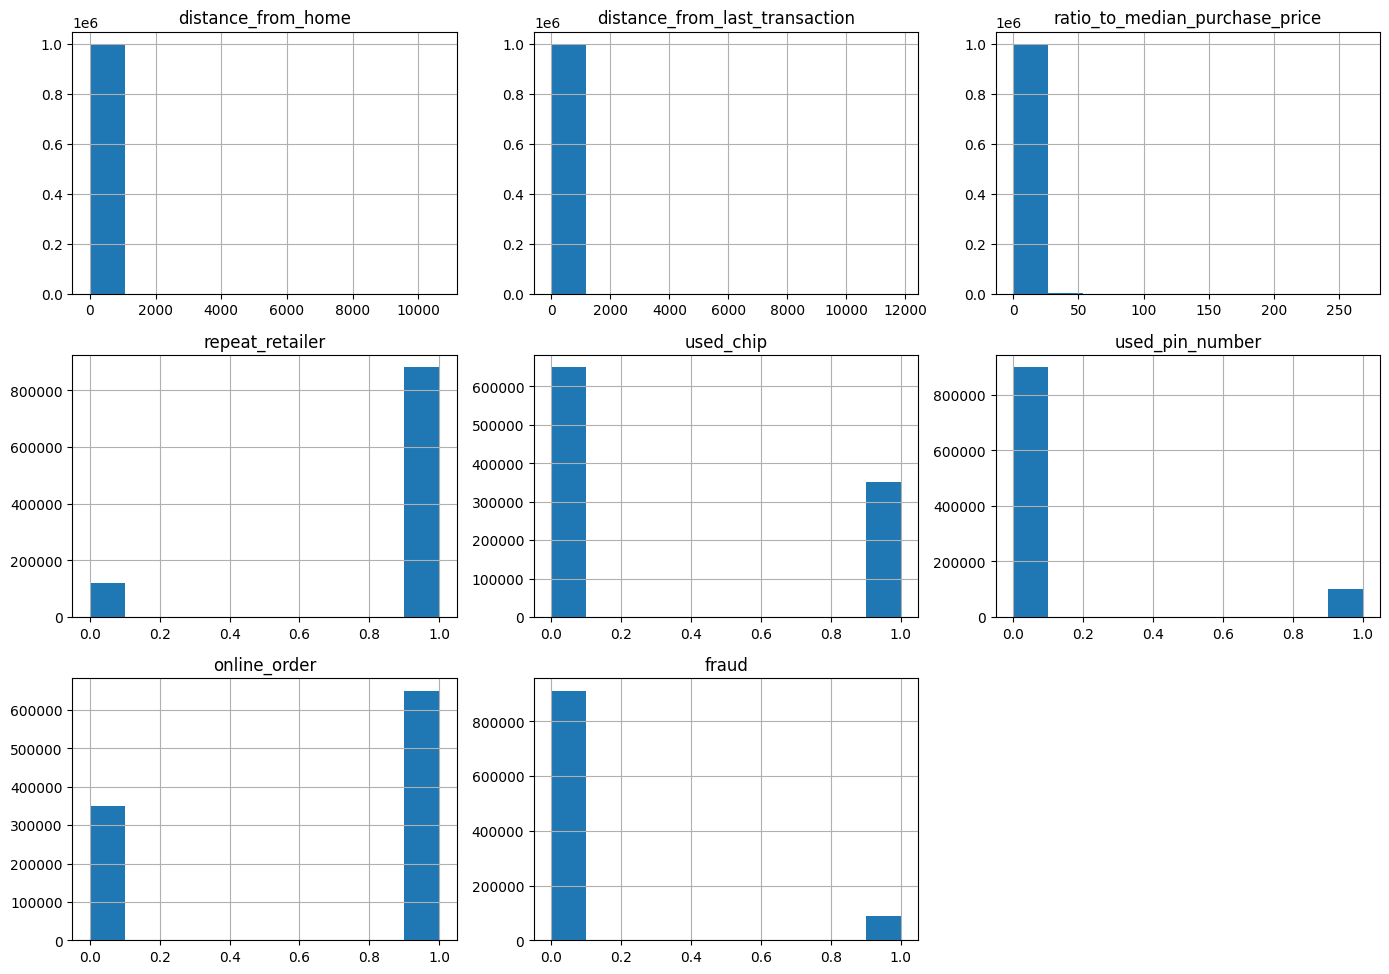

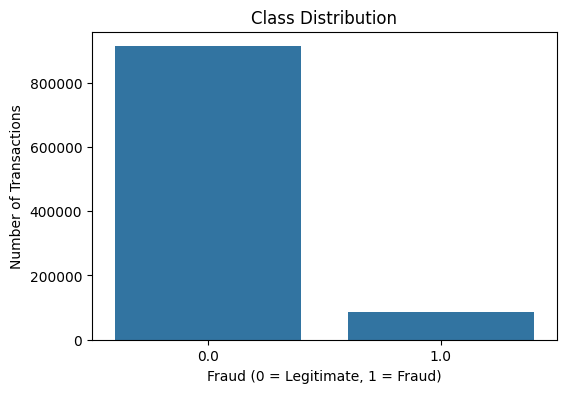

In [ ]:
# TASK 2: Exploratory Data Analysis

# Count legitimate transactions
legitimate = (df["fraud"] == 0).sum()

# Count fraudulent transactions
fraudulent = (df["fraud"] == 1).sum()

# Calculate percentages
legitimate_percentage = (legitimate / len(df)) * 100
fraudulent_percentage = (fraudulent / len(df)) * 100

print("Number of legitimate transactions:", legitimate)
print("Number of fraudulent transactions:", fraudulent)

print("\nPercentage of legitimate transactions:",
      legitimate_percentage)

print("Percentage of fraudulent transactions:",
      fraudulent_percentage)

# Distribution of numerical features
df.hist(figsize=(14, 10))

plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(6, 4))

sns.countplot(x="fraud", data=df)

plt.title("Class Distribution")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

Task 3 — Data Preprocessing

In [ ]:
# TASK 3: Data Preprocessing

# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate records
print("\nNumber of duplicate records:")
print(df.duplicated().sum())

# Identify categorical variables
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("\nCategorical variables:")
print(list(categorical_columns))

# Identify numerical variables
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nNumerical variables:")
print(list(numerical_columns))

# Handle missing values if present
for column in df.columns:
    if df[column].isnull().sum() > 0:
        if df[column].dtype in ["int64", "float64"]:
            df[column] = df[column].fillna(
                df[column].median()
            )

# Remove duplicate records
df = df.drop_duplicates()

print("\nDataset shape after preprocessing:")
print(df.shape)

# Separate features and target
X = df.drop("fraud", axis=1)
y = df["fraud"]

print("\nFeature shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

Missing values in each column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Number of duplicate records:
0

Categorical variables:
[]

Numerical variables:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

Dataset shape after preprocessing:
(1000000, 8)

Feature shape:
(1000000, 7)

Target shape:
(1000000,)


Task 4 — Feature Scaling and Class Imbalance Handling

In [ ]:
# TASK 4: Feature Scaling and Class Imbalance Handling

# Display distribution before balancing
print("Class distribution BEFORE balancing:")
print(y.value_counts())

# Separate majority and minority classes
majority_class = df[df["fraud"] == 0]
minority_class = df[df["fraud"] == 1]

print("\nLegitimate transactions:", len(majority_class))
print("Fraudulent transactions:", len(minority_class))

# Random undersampling of majority class
majority_sample = majority_class.sample(
    n=len(minority_class),
    random_state=42
)

# Combine both classes
balanced_df = pd.concat(
    [majority_sample, minority_class]
)

# Shuffle the data
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate features and target
X_balanced = balanced_df.drop("fraud", axis=1)
y_balanced = balanced_df["fraud"]

# Display distribution after balancing
print("\nClass distribution AFTER balancing:")
print(y_balanced.value_counts())

# Feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_balanced)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_balanced.columns
)

print("\nScaled features:")
print(X_scaled.head())

Class distribution BEFORE balancing:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Legitimate transactions: 912597
Fraudulent transactions: 87403

Class distribution AFTER balancing:
fraud
0.0    87403
1.0    87403
Name: count, dtype: int64

Scaled features:
   distance_from_home  distance_from_last_transaction  \
0           -0.378876                       -0.141911   
1           -0.402776                       -0.220015   
2           -0.266812                        1.375119   
3           -0.368253                       -0.212014   
4           -0.264761                       -0.221043   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                       -0.573562         0.368186  -0.666197   
1                       -0.386886         0.368186   1.501057   
2                       -0.371416         0.368186  -0.666197   
3                        0.149976         0.368186   1.501057   
4                        3.129070         0.368186  -0.666

Task 5 — Split the Dataset

In [ ]:
# TASK 5: Split Dataset

# First split:
# 60% training
# 40% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_balanced,
    test_size=0.40,
    random_state=42,
    stratify=y_balanced
)

# Second split:
# 20% validation
# 20% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (104883, 7)
Validation set: (34961, 7)
Test set: (34962, 7)

Training class distribution:
fraud
1.0    52442
0.0    52441
Name: count, dtype: int64

Validation class distribution:
fraud
0.0    17481
1.0    17480
Name: count, dtype: int64

Test class distribution:
fraud
1.0    17481
0.0    17481
Name: count, dtype: int64


Task 6 — Implement Sigmoid and Cost Functions

In [ ]:
# TASK 6: Sigmoid and Cost Functions

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Binary Cross-Entropy Cost Function
def compute_cost(X, y, w, b):

    m = len(y)

    # Linear prediction
    z = np.dot(X, w) + b

    # Sigmoid prediction
    y_pred = sigmoid(z)

    # Prevent log(0)
    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    # Binary Cross-Entropy
    cost = -(1 / m) * np.sum(
        y * np.log(y_pred)
        +
        (1 - y) * np.log(1 - y_pred)
    )

    return cost


# Test sigmoid
test_values = np.array([-5, -2, 0, 2, 5])

print("Sigmoid values:")
print(sigmoid(test_values))


# Initialize weights and bias
w_initial = np.zeros(X_train.shape[1])
b_initial = 0

# Calculate initial cost
initial_cost = compute_cost(
    X_train.values,
    y_train.values,
    w_initial,
    b_initial
)

print("\nInitial Cost:")
print(initial_cost)

Sigmoid values:
[0.00669285 0.11920292 0.5        0.88079708 0.99330715]

Initial Cost:
0.6931471805599452


Task 7 — Logistic Regression Using Gradient Descent

Model training completed.

Bias:
0.012443119769444975

Weights:
[ 0.5692613   0.31137762  1.24097598 -0.06377853 -0.21593405 -0.44165255
  0.73289541]

Final Cost:
0.3726438582017481


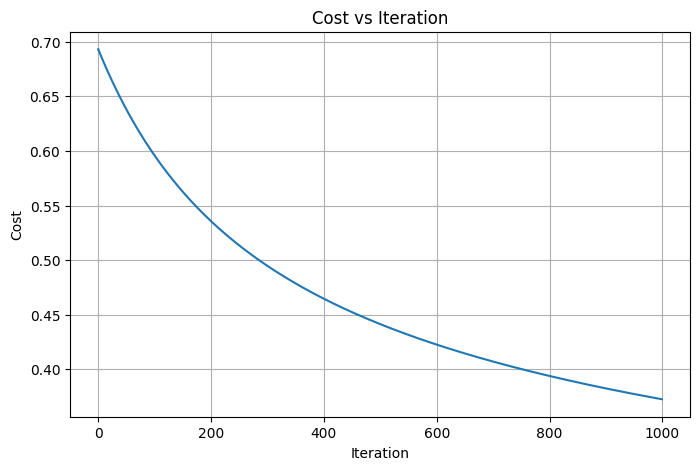

In [ ]:
# TASK 7: Logistic Regression Using Gradient Descent

def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    iterations=1000
):

    # Number of training examples
    m = X.shape[0]

    # Number of features
    n = X.shape[1]

    # Initialize weights
    w = np.zeros(n)

    # Initialize bias
    b = 0

    # Store cost values
    cost_history = []

    # Gradient Descent
    for i in range(iterations):

        # Linear calculation
        z = np.dot(X, w) + b

        # Predicted probability
        y_pred = sigmoid(z)

        # Calculate cost
        cost = compute_cost(
            X,
            y,
            w,
            b
        )

        cost_history.append(cost)

        # Calculate gradient of weights
        dw = (1 / m) * np.dot(
            X.T,
            (y_pred - y)
        )

        # Calculate gradient of bias
        db = (1 / m) * np.sum(
            y_pred - y
        )

        # Update weights
        w = w - learning_rate * dw

        # Update bias
        b = b - learning_rate * db

    return w, b, cost_history


# Train Logistic Regression
w, b, cost_history = train_logistic_regression(
    X_train.values,
    y_train.values,
    learning_rate=0.01,
    iterations=1000
)

print("Model training completed.")

print("\nBias:")
print(b)

print("\nWeights:")
print(w)

print("\nFinal Cost:")
print(cost_history[-1])


# Plot Cost vs Iteration
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")

plt.grid()

plt.show()

Task 8 — Predictions and Confusion Matrix

Confusion Matrix:
[[15856  1625]
 [  849 16632]]

True Negative (TN): 15856
False Positive (FP): 1625
False Negative (FN): 849
True Positive (TP): 16632


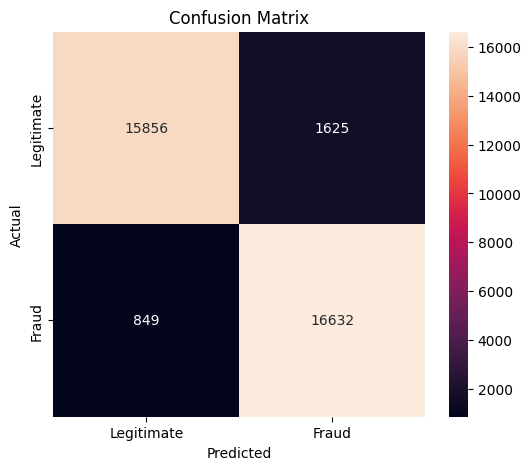

In [ ]:
# TASK 8: Predictions and Confusion Matrix

# Function to calculate probability
def predict_probability(X, w, b):

    z = np.dot(X, w) + b

    return sigmoid(z)


# Function to predict class
def predict_class(X, w, b, threshold=0.5):

    probability = predict_probability(
        X,
        w,
        b
    )

    return (probability >= threshold).astype(int)


# Validation probabilities
y_val_prob = predict_probability(
    X_val.values,
    w,
    b
)

# Validation predictions
y_val_pred = predict_class(
    X_val.values,
    w,
    b
)


# Test probabilities
y_test_prob = predict_probability(
    X_test.values,
    w,
    b
)

# Test predictions
y_test_pred = predict_class(
    X_test.values,
    w,
    b
)


# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Confusion Matrix:")
print(cm)


# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)


# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Task 9 — Precision, Recall, F1-Score and Accuracy

In [ ]:
# TASK 9: Calculate Performance Metrics

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_test_pred
)

# Precision
precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

# Recall
recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

# F1 Score
f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)


# Display results
print("Performance Metrics")
print("===================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Performance Metrics
Accuracy : 0.929237457811338
Precision: 0.9109930437640357
Recall   : 0.9514329843830445
F1-Score : 0.9307739660865185


Task 10 — ROC Curve and AUC

ROC-AUC: 0.9706709183624802


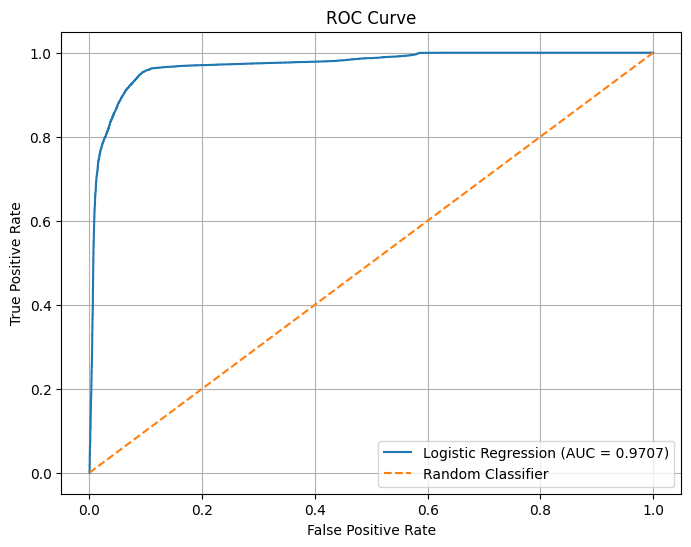


       FINAL PERFORMANCE SUMMARY
Accuracy  : 0.929237457811338
Precision : 0.9109930437640357
Recall    : 0.9514329843830445
F1-Score  : 0.9307739660865185
ROC-AUC   : 0.9706709183624802

Confusion Matrix:
[[15856  1625]
 [  849 16632]]

TN = 15856
FP = 1625
FN = 849
TP = 16632


In [ ]:
# TASK 10: ROC Curve and AUC

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("ROC-AUC:", roc_auc)


# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()


# Final Performance Summary
print("\n======================================")
print("       FINAL PERFORMANCE SUMMARY")
print("======================================")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)
print("ROC-AUC   :", roc_auc)

print("\nConfusion Matrix:")
print(cm)

print("\nTN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)